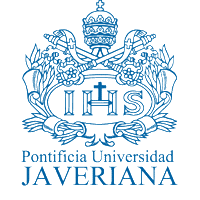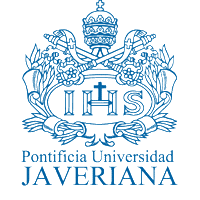
# Pontificia Universidad Javeriana
## Facultad de Ingenieria - Departamento de Ingenieria de Sistemas
### Procesamiento de Datos a Gran Escala (Clase 1255)

**Taller:** Laboratorio Spark

**Estudiante:** Nikholas Barsky Angulo 

**Carrera:** Ciencia de datos

**Maquina virtual asignada:** NBDG44 (IP: 10.43.97.61) 

**Entorno:** Cluster distribuido Apache Spark 4.2.0 con almacenamiento NFS (/opt/cluster) 

**Fecha:** Septiembre 25 de 2026 

---


# Apache Spark - Beginner Tutorial

Firstly, Thank you for checking this tutorial notebook. By now you must have read a lot about Apache Spark and its ML Library.So, I won't bore you with the introduction to Apache-Spark or even the library details. We shall move straight to the interesting stuff i.e. coding.

In this tuorial notebook we will try to compare some of the Apache Spark's Classification Algorithms in an easy way to make predictions. And since this is a beginner's tutorial, we will use the Iris Flower Dataset aka the beginner's dataset in machine learning.

**A quick summary:**

* Import Libraries
* Build Spark Session
* Data Load
* Data Exploration & Preparation
* Feature Engineering
* Data Scaling
* Data Split
* Build, Train & Evaluate Model


In [1]:
# Instalación de PySpark en el entorno local de Python si fuera necesario
# En nuestro caso, el clúster ya cuenta con Apache Spark 4.2.0 configurado en /opt/cluster/spark

#!pip install pyspark --quiet


## Importing Libraries

In [2]:
# 1. IMPORTACIÓN DE LIBRERÍAS

# Librerías base para manejo de estructuras de datos y cálculo numérico
import numpy as np # Operaciones matriciales y numéricas
import pandas as pd # Manipulación de datos tabulares (DataFrames locales)

# Librerías principales de Apache Spark
import pyspark
from pyspark.sql import SparkSession # Punto de entrada para crear DataFrames y gestionar la sesión en el clúster

# Algoritmos de Machine Learning de Spark MLlib para problemas de clasificación
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier, NaiveBayes

# Evaluador para medir el desempeño (Accuracy) en tareas de clasificación multiclase
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Herramientas de ingeniería de características y preprocesamiento de Spark ML
from pyspark.ml.feature import StandardScaler, StringIndexer, VectorAssembler, VectorIndexer, OneHotEncoder

# Pipeline para encadenar transformaciones y modelos si se requiere
from pyspark.ml import Pipeline

# Estructura de vector denso en Spark ML
from pyspark.ml.linalg import DenseVector

# Utilidades complementarias de Scikit-Learn
import sklearn
from sklearn.model_selection import train_test_split

# Librería para imprimir los resultados finales en una tabla limpia y legible
from tabulate import tabulate

# Recolector de basura de Python para liberar memoria residual
import gc


## Build Spark Session

In [3]:
# 2. CONSTRUCCIÓN DE LA SESIÓN DE SPARK (SPARK SESSION)

# Inicializamos la sesión de Spark conectándonos a la infraestructura del clúster.
# Configuramos los recursos asignados por cada executor (1 GB de memoria RAM y 4 núcleos).

spark = (SparkSession.builder
                  .appName('Apache Spark Beginner Tutorial')
                  .config("spark.executor.memory", "1G")
                  .config("spark.executor.cores","4")
                  .getOrCreate())


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [4]:
# Ajustamos el nivel de log a INFO para monitorear el progreso de las tareas distribuidas

spark.sparkContext.setLogLevel('INFO')


In [5]:
# Verificamos la versión de Apache Spark desplegada en el clúster

spark.version


'4.2.0'

## Data Load

In [6]:
# Verificación del sistema de archivos compartido por red (NFS) y procesos del clúster:

# 1. 'df -h' confirma que /opt/cluster está montado desde el nodo principal (10.43.97.58)
# 2. 'ls -la /opt/cluster' lista el contenido de la carpeta compartida (donde reside /data)
# 3. 'jps' valida que los servicios de Worker y Spark estén levantados y activos

!df -h
!ls -la /opt/cluster
!jps


Filesystem                           Size  Used Avail Use% Mounted on
devtmpfs                             7.7G     0  7.7G   0% /dev
tmpfs                                7.7G     0  7.7G   0% /dev/shm
tmpfs                                3.1G   29M  3.1G   1% /run
efivarfs                             256K   44K  208K  18% /sys/firmware/efi/efivars
/dev/mapper/rl_plantillarocky9-root   24G  3.9G   21G  17% /
/dev/sda2                            960M  494M  467M  52% /boot
/dev/sda1                           1022M  7.7M 1015M   1% /boot/efi
/dev/mapper/rl_plantillarocky9-home   15G  1.8G   14G  12% /home
/dev/mapper/rl_plantillarocky9-var    15G  464M   15G   4% /var
10.43.97.58:/opt/cluster              24G  7.6G   17G  32% /opt/cluster
tmpfs                                1.6G  4.0K  1.6G   1% /run/user/1001
total 1110108
drwxrwxrwx.  7 estudiante estudiante      4096 Sep 10 08:35 .
drwxr-xr-x.  4 root       root              34 Aug 18 08:39 ..
-rw-------.  1 estudiante estudiante    

In [7]:
# Copiamos el archivo iris.csv al almacenamiento compartido NFS (/opt/cluster/data/)
# De esta forma, cualquier máquina worker del clúster puede leer el dataset sin errores de archivo local

##  !cp iris.csv /opt/cluster/data/iris.csv
##  !ls -lh /opt/cluster/data/


In [8]:
# 3. CARGA DE DATOS DESDE EL ALMACENAMIENTO COMPARTIDO DEL CLÚSTER

# Definimos la ruta en el volumen NFS compartido accesible por todos los nodos

url = "/opt/cluster/data/iris.csv"

# Leemos el archivo CSV indicando que tiene encabezados (header=true) e infiriendo tipos de datos (inferSchema=true)

data = spark.read.format("csv") \
       .option("header", "true") \
       .option("inferSchema", "true") \
       .load(url)

# Guardamos en caché el DataFrame para agilizar todas las operaciones posteriores en memoria

data.cache()


DataFrame[sepal_length: double, sepal_width: double, petal_length: double, petal_width: double, species: string]

## Data Exploration & Preparation

In [9]:
# Conteo total de registros en el dataset (150 observaciones de flores Iris)

data.count()


150

In [10]:
# Inspección del esquema inferido: tipos de datos numéricos (double) y categóricos (string)

data.printSchema()


root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)
 |-- petal_width: double (nullable = true)
 |-- species: string (nullable = true)



In [11]:
# Visualizamos las primeras 5 filas del DataFrame para corroborar la carga

data.show(5)


+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows


In [12]:
# Agrupamos por la columna 'species' para comprobar la distribución de las 3 clases (50 por cada una, perfectamente balanceado)

data.groupBy('species').count().show()


+----------+-----+
|   species|count|
+----------+-----+
| virginica|   50|
|versicolor|   50|
|    setosa|   50|
+----------+-----+



In [13]:
# Estadísticas descriptivas generales (conteo, media, desviación estándar, valor mínimo y máximo)

data.describe().show()


26/09/13 08:42:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 10:>                                                         (0 + 1) / 1]

+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333335| 3.0540000000000007|3.7586666666666693|1.1986666666666672|     NULL|
| stddev|0.8280661279778637|0.43359431136217375| 1.764420419952262|0.7631607417008414|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   setosa|
|    max|               7.9|                4.4|               6.9|               2.5|virginica|
+-------+------------------+-------------------+------------------+------------------+---------+



Inorder for our model to make predictions the Species aka Label column should be a numerical value (models don't like string!). To achieve this we shall use String Indexing on the Species columns

In [14]:
# 4. PREPROCESAMIENTO: CODIFICACIÓN DE LA ETIQUETA CATEGÓRICA

# Los modelos de Machine Learning requieren etiquetas numéricas en lugar de texto.
# Usamos StringIndexer para mapear cada especie a un valor numérico (0.0, 1.0, 2.0) en 'species_indx'

SIndexer = StringIndexer(inputCol='species', outputCol='species_indx')
data = SIndexer.fit(data).transform(data)

# Verificamos las primeras 5 filas con la nueva columna indexada

data.show(5)


+------------+-----------+------------+-----------+-------+------------+
|sepal_length|sepal_width|petal_length|petal_width|species|species_indx|
+------------+-----------+------------+-----------+-------+------------+
|         5.1|        3.5|         1.4|        0.2| setosa|         0.0|
|         4.9|        3.0|         1.4|        0.2| setosa|         0.0|
|         4.7|        3.2|         1.3|        0.2| setosa|         0.0|
|         4.6|        3.1|         1.5|        0.2| setosa|         0.0|
|         5.0|        3.6|         1.4|        0.2| setosa|         0.0|
+------------+-----------+------------+-----------+-------+------------+
only showing top 5 rows


## Feature Engineering

The Spark model needs two columns: “label” and “features” and we are not going to do much feature engineering because we want to focus on the mechanics of training the model in Spark. 

So, creating a seperate dataframe with re-ordered columns, then defining an input data using Dense Vector. A Dense Vector is a local vector that is backed by a double array that represents its entry values. In other words, it's used to store arrays of values for use in PySpark.


In [15]:
# Reordenamos las columnas del DataFrame colocando la etiqueta indexada al inicio y luego las medidas
df = data.select("species_indx","sepal_length", "sepal_width", "petal_length", "petal_width")

# Inspeccionamos el DataFrame reordenado
df.show(5)


+------------+------------+-----------+------------+-----------+
|species_indx|sepal_length|sepal_width|petal_length|petal_width|
+------------+------------+-----------+------------+-----------+
|         0.0|         5.1|        3.5|         1.4|        0.2|
|         0.0|         4.9|        3.0|         1.4|        0.2|
|         0.0|         4.7|        3.2|         1.3|        0.2|
|         0.0|         4.6|        3.1|         1.5|        0.2|
|         0.0|         5.0|        3.6|         1.4|        0.2|
+------------+------------+-----------+------------+-----------+
only showing top 5 rows


**Note:** Observe that the species column which is our label (aka Target) is now at beginning of the dataframe

In [16]:
# 5. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING CON VECTORASSEMBLER)

# Spark ML exige que todas las variables predictoras se encuentren empaquetadas en una única columna de tipo Vector.
# Empleamos VectorAssembler, que es la herramienta nativa de Spark MLlib ejecutada directamente en la JVM.
# Esto asegura máximo rendimiento y compatibilidad sin requerir workers de Python en los nodos ejecutores.

assembler = VectorAssembler(
    inputCols=["sepal_length", "sepal_width", "petal_length", "petal_width"],
    outputCol="features"
)

# Generamos el DataFrame final renombrando la variable objetivo a 'label' y seleccionando 'features'

df_indx = assembler.transform(df).withColumnRenamed("species_indx", "label").select("label", "features")


**Note:** Observe the definition of the Dense Vector. So,when we create a new indexed dataframe(below) the machine understands that the first column is a Label (Target) and the remaining columns are Features.

In [17]:
# Inspeccionamos la estructura del DataFrame indexado con 'label' y el vector 'features'

df_indx.show(5)


+-----+-----------------+
|label|         features|
+-----+-----------------+
|  0.0|[5.1,3.5,1.4,0.2]|
|  0.0|[4.9,3.0,1.4,0.2]|
|  0.0|[4.7,3.2,1.3,0.2]|
|  0.0|[4.6,3.1,1.5,0.2]|
|  0.0|[5.0,3.6,1.4,0.2]|
+-----+-----------------+
only showing top 5 rows


In [18]:
# Verificamos nuevamente las 5 primeras filas para confirmar que el vector de características esté correcto

df_indx.show(5)


+-----+-----------------+
|label|         features|
+-----+-----------------+
|  0.0|[5.1,3.5,1.4,0.2]|
|  0.0|[4.9,3.0,1.4,0.2]|
|  0.0|[4.7,3.2,1.3,0.2]|
|  0.0|[4.6,3.1,1.5,0.2]|
|  0.0|[5.0,3.6,1.4,0.2]|
+-----+-----------------+
only showing top 5 rows


## Data Scaling

This is also known as Feature Scaling. It is a method of normalizing the features of the data. Scaling can make a difference between a weak machine learning model and a better one. 

In this tutorial we will use a Standard Scaler to scale our feature data. Apache Spark has a Standard Scaler library to do the job.

In [19]:
# 6. ESCALADO DE CARACTERÍSTICAS (FEATURE SCALING CON STANDARDSCALER)

# Normalizamos las características para que tengan varianza unitaria (desviación estándar = 1).
# Esto evita que variables con magnitudes mayores dominen el cálculo de distancias en los algoritmos.

stdScaler = StandardScaler(inputCol="features", outputCol="features_scaled")

# Ajustamos el escalador con los datos (.fit) para calcular las estadísticas necesarias

scaler = stdScaler.fit(df_indx)

# Aplicamos la transformación (.transform) para obtener la columna 'features_scaled'

df_scaled = scaler.transform(df_indx)


In [20]:
# Revisamos los vectores de características normalizados

df_scaled.show(5)


+-----+-----------------+--------------------+
|label|         features|     features_scaled|
+-----+-----------------+--------------------+
|  0.0|[5.1,3.5,1.4,0.2]|[6.15892840883878...|
|  0.0|[4.9,3.0,1.4,0.2]|[5.9174018045706,...|
|  0.0|[4.7,3.2,1.3,0.2]|[5.67587520030241...|
|  0.0|[4.6,3.1,1.5,0.2]|[5.55511189816831...|
|  0.0|[5.0,3.6,1.4,0.2]|[6.03816510670469...|
+-----+-----------------+--------------------+
only showing top 5 rows


In [21]:
# Eliminamos la columna original 'features' sin escalar para mantener solo la versión estandarizada

df_scaled = df_scaled.drop("features")


## Data Split

Just like always, before building a model we shall split our scaled dataset into training & test sets. 
Training Dataset = 90%
Test Dataset = 10%

In [22]:
# 7. PARTICIÓN DEL DATASET (TRAIN / TEST SPLIT)

# Dividimos el conjunto de datos de forma aleatoria: 90% para entrenamiento y 10% para evaluación.
# Fijamos la semilla (seed=12345) para garantizar reproducibilidad exacta en futuras ejecuciones.

train_data, test_data = df_scaled.randomSplit([0.9, 0.1], seed = 12345)


In [23]:
# Inspeccionamos los primeros registros del conjunto de entrenamiento

train_data.show(5)


+-----+--------------------+
|label|     features_scaled|
+-----+--------------------+
|  0.0|[5.19282199176603...|
|  0.0|[5.31358529390013...|
|  0.0|[5.31358529390013...|
|  0.0|[5.31358529390013...|
|  0.0|[5.43434859603422...|
+-----+--------------------+
only showing top 5 rows


## Build, Train & Evaluate Model

In this step we will create multiple models, train them on our scaled dataset and then compare their accuracy.

In [24]:
# 8. CONSTRUCCIÓN, ENTRENAMIENTO Y COMPARACIÓN DE MODELOS

# Definimos las listas donde registraremos los algoritmos a comparar y sus métricas de exactitud

model = ['Decision Tree','Random Forest','Naive Bayes']
model_results = []


In [25]:
# ------------------------------------------------------------------------------
# MODELO 1: ÁRBOL DE DECISIÓN (DECISION TREE CLASSIFIER)
# ------------------------------------------------------------------------------

# Instanciamos el modelo indicando la columna etiqueta y las características escaladas
dtc = DecisionTreeClassifier(labelCol="label", featuresCol="features_scaled")

# Entrenamos el árbol de decisión sobre el 90% de los datos
dtc_model = dtc.fit(train_data)

# Generamos predicciones sobre el 10% de prueba que el modelo nunca vio
dtc_pred = dtc_model.transform(test_data)

# Evaluamos la exactitud (Accuracy) contrastando las predicciones contra las etiquetas reales
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dtc_acc = evaluator.evaluate(dtc_pred)

# Añadimos el resultado a la lista comparativa con formato de porcentaje
model_results.extend([[model[0], '{:.2%}'.format(dtc_acc)]])


In [26]:
# ------------------------------------------------------------------------------
# MODELO 2: BOSQUE ALEATORIO (RANDOM FOREST CLASSIFIER)
# ------------------------------------------------------------------------------

# Instanciamos el clasificador de ensamble configurando un total de 10 árboles de decisión
rfc = RandomForestClassifier(labelCol="label", featuresCol="features_scaled", numTrees=10)

# Entrenamos el ensamble sobre el conjunto de entrenamiento
rfc_model = rfc.fit(train_data)

# Evaluamos las predicciones sobre el conjunto de prueba
rfc_pred = rfc_model.transform(test_data)

# Calculamos la métrica de Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rfc_acc = evaluator.evaluate(rfc_pred)

# Añadimos el resultado a la lista comparativa
model_results.extend([[model[1], '{:.2%}'.format(rfc_acc)]])


In [27]:
# ------------------------------------------------------------------------------
# MODELO 3: CLASIFICADOR BAYESIANO INGENUO (NAIVE BAYES)
# ------------------------------------------------------------------------------

# Instanciamos Naive Bayes con suavizado de Laplace (smoothing=1.0) bajo modelo multinomial
nbc = NaiveBayes(smoothing=1.0, modelType="multinomial", labelCol="label", featuresCol="features_scaled")

# Entrenamos el modelo con los datos de entrenamiento
nbc_model = nbc.fit(train_data)

# Obtenemos las predicciones sobre el conjunto de prueba
nbc_pred = nbc_model.transform(test_data)

# Evaluamos la métrica de Accuracy
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
nbc_acc = evaluator.evaluate(nbc_pred)

# Añadimos el resultado a la lista comparativa
model_results.extend([[model[2], '{:.2%}'.format(nbc_acc)]])


In [28]:
# Liberamos memoria RAM en el proceso local forzando el recolector de basura

gc.collect()


625

Tabulating the results.

In [29]:
# 9. TABULACIÓN COMPARATIVA DE RESULTADOS FINALES

# Imprimimos la tabla con el Accuracy final obtenido por cada algoritmo sobre el conjunto de prueba

print(tabulate(model_results, headers=["Classifier Models", "Accuracy"]))


Classifier Models    Accuracy
-------------------  ----------
Decision Tree        90.91%
Random Forest        100.00%
Naive Bayes          100.00%


## Análisis de Resultados

Después de entrenar y evaluar los tres modelos de clasificación sobre el conjunto de prueba, correspondiente al 10% de los datos (11 registros), se obtuvieron los siguientes resultados:

### 1. Decision Tree Classifier - 90.91%

El árbol de decisión clasificó correctamente 10 de las 11 muestras. Este resultado es razonable para el dataset Iris, ya que la especie *setosa* se diferencia fácilmente, mientras que *versicolor* y *virginica* tienen características más similares. Por esta razón, una muestra cercana al límite entre estas dos clases pudo haber sido clasificada incorrectamente.

### 2. Random Forest Classifier - 100%

Random Forest alcanzó una exactitud del 100%. En este caso se utilizaron 10 árboles (`numTrees=10`), cuyos resultados se combinan para obtener la clasificación final. Al utilizar varios árboles en lugar de uno solo, el modelo reduce la posibilidad de cometer errores individuales y genera una clasificación más estable.

### 3. Naive Bayes Classifier - 100%

Naive Bayes también obtuvo una exactitud del 100%. Aunque este algoritmo supone que las características son independientes entre sí, algo que no necesariamente se cumple en el dataset Iris, las diferencias entre las clases fueron suficientes para clasificar correctamente todas las muestras del conjunto de prueba. Además, se utilizó `StandardScaler` con la configuración por defecto de Spark (`withMean=False`), lo que permitió mantener los valores escalados no negativos, condición necesaria para trabajar con Naive Bayes multinomial.

## Conclusiones

Los resultados muestran que Random Forest y Naive Bayes tuvieron un mejor desempeño que Decision Tree en este experimento. También se utilizaron `VectorAssembler` y `StandardScaler` para preparar las características antes del entrenamiento de los modelos.Sin embargo, es importante tener en cuenta que el conjunto de prueba solo tenía 11 registros, por lo que un solo error cambia la exactitud aproximadamente un 9.09%.

![](https://www.appreciationatwork.com/wp-content/uploads/2018/01/thank-you.jpg)

I hope this tutorial was helpful.